O conhecimento é um conjunto de proposições em uma linguagem.<br>
Pode ser obtido de duas formas principais:
- **Especialista**: levantado a partir de sessões de engenharia do conhecimento, como nos sistemas especialistas clássicos.
- **Dados**: extraído a partir de padrões ou categorias encontrados em conjuntos de dados coletados nos sistemas que se quer representar.

**Especialista:**  
O conhecimento é obtido por meio de entrevistas, questionários ou sessões de engenharia do conhecimento com especialistas humanos, sendo formalizado em regras ou proposições lógicas.

**Dados:**  
O conhecimento é extraído automaticamente a partir de padrões, categorias ou relações identificadas em grandes conjuntos de dados, utilizando técnicas como mineração de dados ou aprendizado de máquina.

Representação de conhecimento através de regras permite modelar a experiência humana em situações específicas.  
Essas regras são fundamentais para capturar o raciocínio de especialistas e automatizar decisões em sistemas computacionais.

Nos sistemas fuzzy, tanto as premissas quanto as conclusões podem ser proposições fuzzy, permitindo lidar com incertezas e imprecisões presentes no conhecimento humano.

Nos sistemas fuzzy, premissas e conclusões podem ser proposições fuzzy, ou seja, as regras descrevem ações a serem tomadas sob condições específicas, permitindo maior flexibilidade e adaptação a situações com incerteza.

**Variável numérica:**  
Assume um valor numérico específico, por exemplo: temperatura = 75°C.

**Variável linguística:**  
Utilizada para representar de modo impreciso um conceito ou variável. É associada a valores linguísticos (como jovem, velho, alto, baixo, gordo, magro, quente, frio, etc.), que correspondem a conjuntos fuzzy.  
Esses valores linguísticos são conectados a valores numéricos por meio de funções de pertinência.

Os termos primários de uma variável linguística formam a sua estrutura de conhecimento, conhecida como partição fuzzy dessa variável.

Formalmente, uma família de conjuntos fuzzy {A₁, A₂, ..., Aₙ} constitui uma partição fuzzy A em um universo de discurso U se obedecer às seguintes propriedades:
- Para cada elemento deste universo, existe pelo menos um conjunto fuzzy no qual o seu grau de pertinência seja não-nulo.
- Os elementos de A são conjuntos fuzzy unimodais e convexos.

**Exemplo:**  
Considere a variável linguística "temperatura" com os termos primários: "frio", "morno" e "quente".  
Cada termo é representado por um conjunto fuzzy sobre o universo de discurso (por exemplo, de 0°C a 40°C).  
Para cada valor de temperatura, existe pelo menos um termo com grau de pertinência não nulo, e os conjuntos são unimodais e convexos, formando assim uma partição fuzzy.

Uma variável linguística é formalmente caracterizada por uma quíntupla (x, t(x), U, G, M), onde:
- **x**: nome da variável linguística
- **t(x)**: conjunto de termos linguísticos (valores linguísticos)
- **U**: universo de discurso (intervalo de valores possíveis)
- **G**: conjunto de funções de geração dos termos linguísticos
- **M**: conjunto de funções de pertinência associadas aos termos

**Exemplo:**  
Para a variável linguística "temperatura":
- x = "temperatura"
- t(x) = {"frio", "morno", "quente"}
- U = [0°C, 40°C]
- G = funções que geram os termos a partir de U
- M = funções de pertinência que associam cada valor de U a um grau de pertinência em cada termo

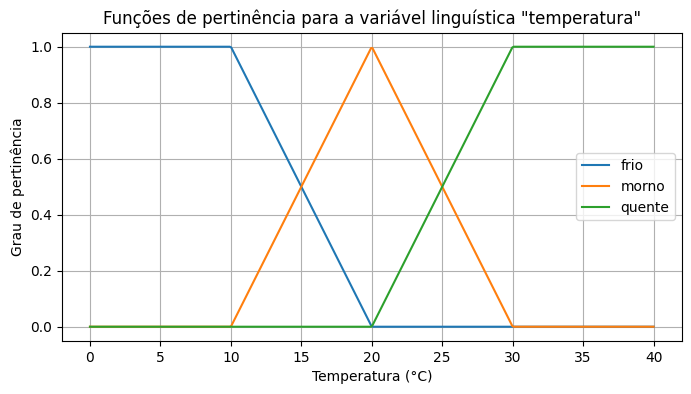

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Universo de discurso
U = np.linspace(0, 40, 400)

# Funções de pertinência (exemplo típico)
def frio(x):
    return np.maximum(0, np.minimum(1, (20 - x) / 10))

def morno(x):
    return np.maximum(0, np.minimum((x - 10) / 10, (30 - x) / 10))

def quente(x):
    return np.maximum(0, np.minimum(1, (x - 20) / 10))

plt.figure(figsize=(8,4))
plt.plot(U, frio(U), label='frio')
plt.plot(U, morno(U), label='morno')
plt.plot(U, quente(U), label='quente')
plt.title('Funções de pertinência para a variável linguística "temperatura"')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Grau de pertinência')
plt.legend()
plt.grid(True)
plt.show()

**Detalhamento dos componentes G e M:**

- **G (funções geradoras dos termos):**  
  São funções ou regras que definem como cada termo linguístico (por exemplo, "frio", "morno", "quente") é construído a partir do universo de discurso U.  
  Por exemplo, podem ser funções que determinam os intervalos ou regiões do universo de discurso associadas a cada termo.

- **M (funções de pertinência):**  
  Para cada termo linguístico, existe uma função de pertinência que associa a cada valor de U um grau de pertencimento ao termo.  
  Essas funções determinam, para cada valor numérico, o quanto ele representa o termo linguístico correspondente, variando de 0 (não pertence) a 1 (pertence totalmente).

**Explicação detalhada de G e M:**

- **G (funções geradoras dos termos):**  
  São mecanismos que definem como os termos linguísticos são criados a partir do universo de discurso.  
  Por exemplo, para a variável "temperatura", G pode especificar que o termo "frio" será representado por um conjunto fuzzy centrado em 10°C, "morno" em 20°C e "quente" em 30°C, cada um com uma largura específica.  
  G pode ser implementado por funções matemáticas (como funções triangulares, trapezoidais ou gaussianas) que determinam a forma e a posição dos conjuntos fuzzy no universo de discurso.

- **M (funções de pertinência):**  
  Para cada termo linguístico, M define uma função que, dado um valor numérico do universo de discurso, retorna o grau de pertencimento desse valor ao termo.  
  Por exemplo, para "frio", a função de pertinência pode ser uma função triangular que vale 1 em 10°C e decresce até 0 em 0°C e 20°C.  
  Assim, se a temperatura for 15°C, a função de pertinência de "frio" pode retornar 0.5, indicando que 15°C é parcialmente "frio".

**Exemplo de estrutura sintática de uma regra fuzzy:**  
- Se &lt;antecedente&gt; Então &lt;consequente&gt;  
- Se &lt;x é A&gt; Então &lt;y é B&gt;  
Onde "x" e "y" são variáveis linguísticas, e "A" e "B" são termos linguísticos (conjuntos fuzzy).

Uma regra fuzzy é uma relação fuzzy a partir da qual é possível obter um valor de pertinência (grau de ativação) para cada entrada, indicando o quanto aquela regra está sendo ativada para um dado conjunto de valores de entrada.

O conjunto das regras fuzzy resulta em uma relação fuzzy global, obtida pela agregação das relações (regras) individuais por meio de um operador de agregação, geralmente uma s-norma (como o máximo).  
Em alguns casos, t-normas (como o mínimo) também podem ser usadas para combinar os graus de ativação das regras.

**Método de Inferência baseado na Lógica Booleana:**  
A inferência é realizada a partir de uma proposição verdadeira A e uma implicação do tipo A → B.

- Premissa 1 (fato): x é A  
- Premissa 2 (regra): Se x é A então y é B  
———————————————————  
- Consequência (conclusão): y é B

Ou seja, sabendo que &lt;x é A&gt; é verdade, pode-se inferir que &lt;y é B&gt; também é verdade.

**Exemplo prático:**  
- Premissa 1 (fato): O tomate está vermelho  
- Premissa 2 (regra): Se o tomate está vermelho então o tomate está maduro  
—————————————————————————————————————  
- Consequência (conclusão): O tomate está maduro

Ou seja, sabendo que o tomate está vermelho, pode-se inferir que o tomate está maduro.

**O que é uma variável linguística e um termo linguístico?**

- **Variável linguística:**  
  É uma variável cujo valor não é um número exato, mas sim uma palavra ou expressão da linguagem natural.  
  Exemplo: "temperatura", "idade", "velocidade".

- **Termo linguístico:**  
  É um valor possível que a variável linguística pode assumir, representando um conceito vago ou subjetivo.  
  Exemplo: para a variável "temperatura", os termos linguísticos podem ser "frio", "morno" e "quente".  
  Cada termo linguístico é associado a um conjunto fuzzy que define, para cada valor numérico, o grau em que ele representa esse termo.

**Identificação no exemplo do tomate:**

- **Variável linguística:**  
  "cor do tomate" e "estado do tomate" são variáveis linguísticas, pois representam características descritas por palavras.

- **Termo linguístico:**  
  "vermelho" (para a variável "cor do tomate") e "maduro" (para a variável "estado do tomate") são termos linguísticos, pois são valores qualitativos associados a essas variáveis.

**Raciocínio Fuzzy ou Aproximado:**  
Em sistemas fuzzy, uma conclusão é obtida a partir de fatos e da composição de regras fuzzy (inferência) do tipo Se-Então.  
Essas regras são interpretadas como relações fuzzy e modelam sentenças em linguagem natural por meio de variáveis e valores linguísticos.

O processo de obtenção da conclusão é chamado de raciocínio fuzzy (ou raciocínio aproximado) e é baseado no Modus Ponens Generalizado, permitindo lidar com incertezas e imprecisões presentes nas informações.

**Exemplo prático de raciocínio fuzzy:**

- Premissa 1 (fato): O tomate está muito vermelho  
- Premissa 2 (regra): Se o tomate está vermelho então o tomate está maduro  
—————————————————————————————————————  
- Consequência (conclusão): O tomate está muito maduro

Neste caso, "muito vermelho" (A′) é um conjunto fuzzy próximo de "vermelho" (A), e "muito maduro" (B′) é um conjunto fuzzy próximo de "maduro" (B).  
Assim, se o fato é parcialmente verdadeiro (grau elevado de "vermelho"), a conclusão também será parcialmente verdadeira (grau elevado de "maduro").

**Interpretação da regra fuzzy e cálculo da conclusão:**

- Uma regra fuzzy do tipo "Se x é A então y é B" pode ser interpretada como uma relação fuzzy $R$ entre os universos $X$ e $Y$, ou seja, $R = A \rightarrow B$.
- Quando temos um fato "$x$ é $A'$" ($A'$ é um conjunto fuzzy), a conclusão "$y$ é $B'$" também será um conjunto fuzzy, obtido pela composição de $A'$ com a relação $R$.

A composição é feita assim:  
- $B' = A' \circ R = A' \circ (A \rightarrow B)$

O grau de pertinência de $y$ em $B'$ é calculado por:  
- $\mu_{B'}(y) = \max_x \min[\mu_{A'}(x), \mu_R(x, y)]$

Ou seja, para cada valor de $y$, verifica-se todos os valores possíveis de $x$, calcula-se o mínimo entre o grau de pertinência de $x$ em $A'$ e o grau de pertinência da relação $R$ para $(x, y)$, e toma-se o máximo desses valores.  
Isso garante que a conclusão fuzzy ($B'$) reflita tanto o fato observado ($A'$) quanto a regra fuzzy ($R$).

**Exemplo detalhado de inferência fuzzy:**

Considere:
- Universo $X = [0, 10]$ e $Y = [0, 10]$
- $A$ (em $X$): "próximo de 7" (triangular com pico em 7)
- $A'$ (em $X$): "próximo de 8" (triangular com pico em 8)
- $B$ (em $Y$): "próximo de 3" (triangular com pico em 3)
- Regra: Se $x$ é $A$ então $y$ é $B$

Dado o fato $x$ é $A'$, a conclusão será $y$ é $B'$, onde $B'$ é obtido pela composição:
$$
\mu_{B'}(y) = \max_x \min[\mu_{A'}(x), \mu_R(x, y)]
$$
onde $\mu_R(x, y) = \min[\mu_A(x), \mu_B(y)]$ (implicação de Mamdani).

O gráfico abaixo mostra $A$, $A'$, $B$, $B'$, R$ e a superfície de ativação.

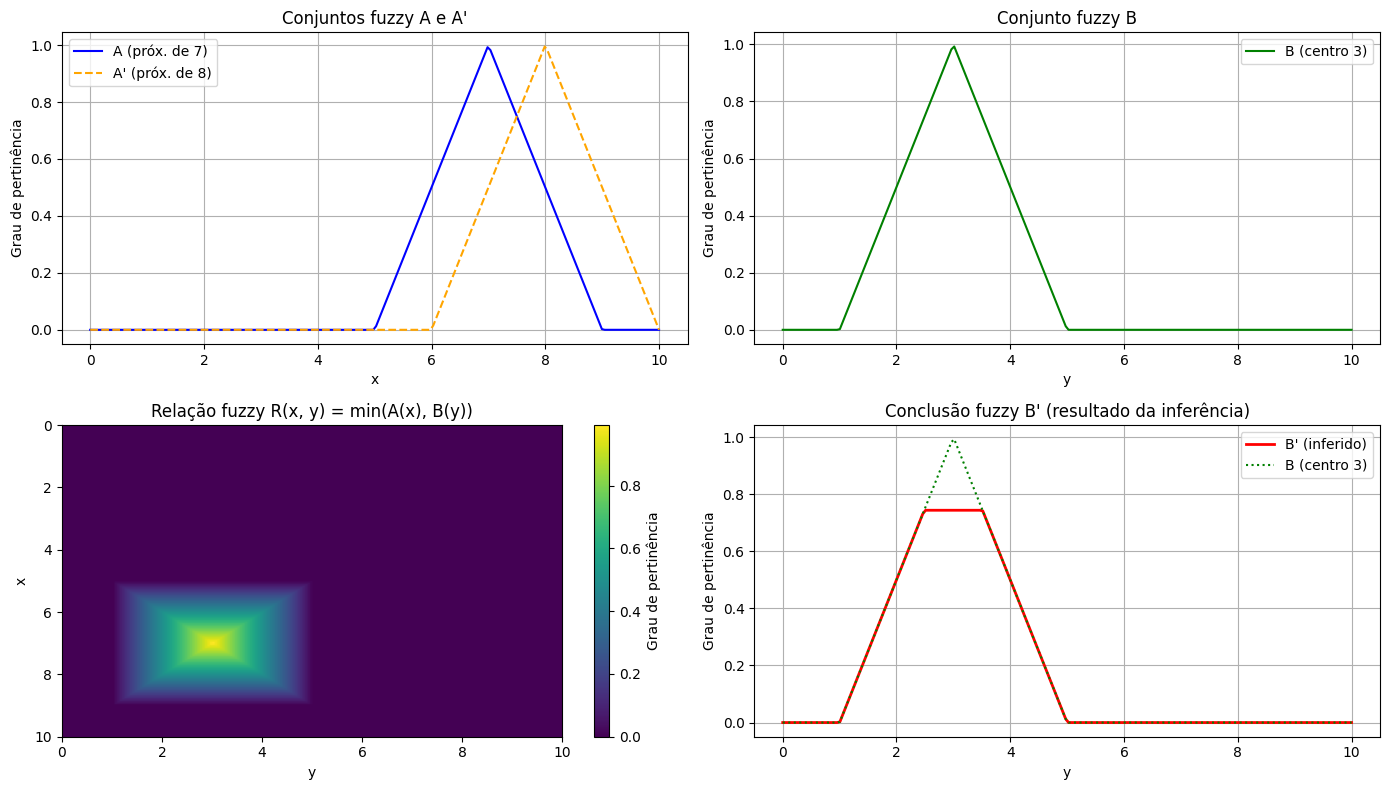

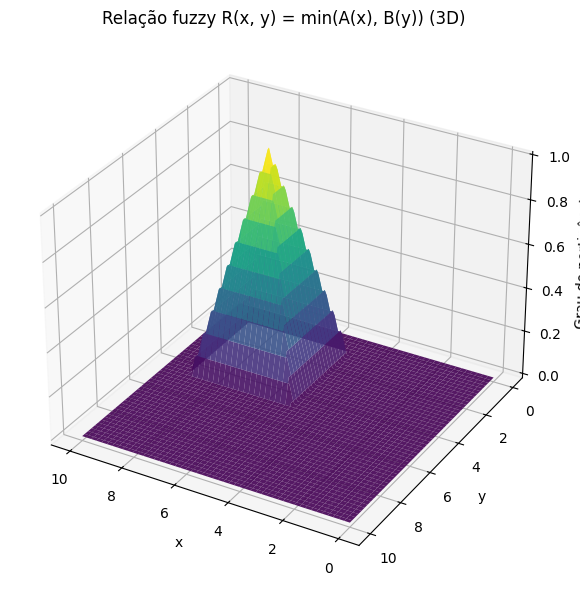

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Universo
X = np.linspace(0, 10, 200)
Y = np.linspace(0, 10, 200)

def mu_A(x):   # Triangular em 7
    return np.maximum(0, 1 - np.abs(x - 7)/2)
def mu_Ap(x):  # Triangular em 8
    return np.maximum(0, 1 - np.abs(x - 8)/2)
def mu_B(y):   # Triangular em 3
    return np.maximum(0, 1 - np.abs(y - 3)/2)

# Relação fuzzy R(x, y) = min(mu_A(x), mu_B(y))
R = np.minimum.outer(mu_A(X), mu_B(Y))  # shape (len(X), len(Y))

# Composição: mu_Bp(y) = max_x min(mu_Ap(x), R(x, y))
mu_Ap_X = mu_Ap(X)[:, np.newaxis]  # shape (len(X), 1)
min_matrix = np.minimum(mu_Ap_X, R)  # shape (len(X), len(Y))
mu_Bp = np.max(min_matrix, axis=0)   # shape (len(Y),)

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Plot A e A'
axs[0, 0].plot(X, mu_A(X), label="A (próx. de 7)", color='blue')
axs[0, 0].plot(X, mu_Ap(X), label="A' (próx. de 8)", color='orange', linestyle='--')
axs[0, 0].set_title("Conjuntos fuzzy A e A'")
axs[0, 0].set_xlabel("x")
axs[0, 0].set_ylabel("Grau de pertinência")
axs[0, 0].legend()
axs[0, 0].grid(True)

# Plot B
axs[0, 1].plot(Y, mu_B(Y), label="B (centro 3)", color='green')
axs[0, 1].set_title("Conjunto fuzzy B")
axs[0, 1].set_xlabel("y")
axs[0, 1].set_ylabel("Grau de pertinência")
axs[0, 1].legend()
axs[0, 1].grid(True)

# Heatmap da relação fuzzy R(x, y)
im = axs[1, 0].imshow(R, extent=[Y[0], Y[-1], X[-1], X[0]], aspect='auto', cmap='viridis')
axs[1, 0].set_title("Relação fuzzy R(x, y) = min(A(x), B(y))")
axs[1, 0].set_xlabel("y")
axs[1, 0].set_ylabel("x")
fig.colorbar(im, ax=axs[1, 0], label="Grau de pertinência")

# Plot B'
axs[1, 1].plot(Y, mu_Bp, label="B' (inferido)", color='red', linewidth=2)
axs[1, 1].plot(Y, mu_B(Y), label="B (centro 3)", color='green', linestyle=':')
axs[1, 1].set_title("Conclusão fuzzy B' (resultado da inferência)")
axs[1, 1].set_xlabel("y")
axs[1, 1].set_ylabel("Grau de pertinência")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Plot 3D separado da relação fuzzy R(x, y)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
Xg, Yg = np.meshgrid(X, Y, indexing='ij')
ax.plot_surface(Xg, Yg, R, cmap='viridis', edgecolor='none', alpha=0.9)
ax.set_title("Relação fuzzy R(x, y) = min(A(x), B(y)) (3D)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Grau de pertinência")
ax.view_init(elev=30, azim=120)
plt.tight_layout()
plt.show()

**Inferência fuzzy para regra com duas premissas:**

Regra: Se $x$ é $A$ e $y$ é $B$ então $z$ é $C$  
Fato: $x$ é $A'$ e $y$ é $B'$

Conclusão: $z$ é $C'$

A força de ativação da regra é:
$$
w_1 = \max_x [\mu_{A'}(x) \wedge \mu_A(x)]
$$
$$
w_2 = \max_y [\mu_{B'}(y) \wedge \mu_B(y)]
$$

A saída fuzzy é:
$$
\mu_{C'}(z) = (w_1 \wedge w_2) \wedge \mu_C(z)
$$

Ou seja, $C'$ é o conjunto $C$ recortado pelo grau de ativação mínimo entre $w_1$ e $w_2$.

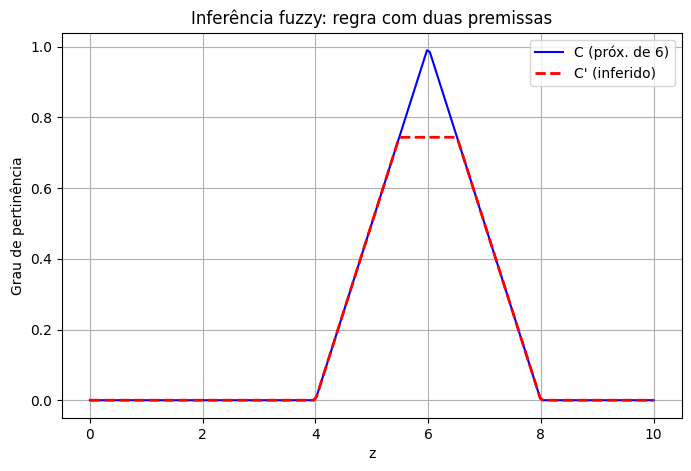

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Universo
X = np.linspace(0, 10, 200)
Y = np.linspace(0, 10, 200)
Z = np.linspace(0, 10, 200)

# Conjuntos fuzzy
def mu_A(x):   # Triangular em 7
    return np.maximum(0, 1 - np.abs(x - 7)/2)
def mu_Ap(x):  # Triangular em 8
    return np.maximum(0, 1 - np.abs(x - 8)/2)
def mu_B(y):   # Triangular em 3
    return np.maximum(0, 1 - np.abs(y - 3)/2)
def mu_Bp(y):  # Triangular em 2
    return np.maximum(0, 1 - np.abs(y - 2)/2)
def mu_C(z):   # Triangular em 6
    return np.maximum(0, 1 - np.abs(z - 6)/2)

# Força de ativação
w1 = np.max(np.minimum(mu_Ap(X), mu_A(X)))
w2 = np.max(np.minimum(mu_Bp(Y), mu_B(Y)))
w = min(w1, w2)

# Conclusão fuzzy C'
mu_Cp = np.minimum(w, mu_C(Z))

# Plot
plt.figure(figsize=(8,5))
plt.plot(Z, mu_C(Z), label="C (próx. de 6)", color='blue')
plt.plot(Z, mu_Cp, label="C' (inferido)", color='red', linestyle='--', linewidth=2)
plt.title("Inferência fuzzy: regra com duas premissas")
plt.xlabel("z")
plt.ylabel("Grau de pertinência")
plt.legend()
plt.grid(True)
plt.show()

**Projeto de Sistema Fuzzy Baseado em Regras**

1. **Definição das variáveis de entrada (x) e saída (y):**  
   Identifique quais variáveis do sistema serão entradas (ex: temperatura, velocidade) e qual será a saída (ex: potência, classificação).

2. **Definição dos universos de discurso das variáveis x e y:**  
   Estabeleça os intervalos numéricos possíveis para cada variável (ex: temperatura de 0°C a 40°C).

3. **Definição do mecanismo de inferência:**  
   Escolha o método de inferência fuzzy (ex: Mamdani, Sugeno).

4. **Definição das funções de pertinência (número e tipo) das variáveis x e y:**  
   Para cada variável, defina quantos termos linguísticos (ex: baixo, médio, alto) e o tipo de função de pertinência (triangular, trapezoidal, gaussiana).

5. **Definição dos operadores:**  
   - **AND:** geralmente mínimo ($\min$) ou produto  
   - **OR:** geralmente máximo ($\max$)  
   - **Implicação:** mínimo ou produto  
   - **Agregação de regras:** máximo  
   - **Defuzzificação:** centroide, média dos máximos, etc.

6. **Definição da base de regras:**  
   Escreva as regras do tipo "Se x é A e y é B então z é C", cobrindo todas as situações relevantes.

7. **Ajustes necessários:**  
   Ajuste os parâmetros das funções de pertinência, revise as regras e operadores conforme o desempenho do sistema fuzzy.

**Funcionamento da máquina de inferência fuzzy**

- A máquina de inferência processa as regras existentes no banco de conhecimento e gera um conjunto fuzzy de saída, a partir da composição de todas as regras ativadas.
- Uma regra é considerada ativada quando o processamento do antecedente para as entradas atuais resulta em graus de pertinência não-nulos.
- O módulo de interface de saída (defuzzificação) recebe um conjunto fuzzy para cada variável de saída e o converte em um valor escalar correspondente, gerando saídas compatíveis com sistemas externos.

**Fuzzificação e ativação das regras:**
- Durante a conversão de valores escalares (entradas) para fuzzy, os antecedentes de cada regra são processados por meio da interseção fuzzy entre os graus de pertinência das entradas atuais nos termos primários definidos.
- Isso gera um grau de pertinência de ativação para cada regra (coeficiente de ativação).
- Esse processamento transforma informações quantitativas em qualitativas (fuzzificação).

**Composição da saída:**
- Todas as regras com coeficiente de ativação maior que zero são consideradas ativadas e contribuem para o cálculo da saída.
- Os coeficientes de ativação limitam os valores máximos dos conjuntos fuzzy de saída gerados por cada regra.
- Uma operação global de união (geralmente máximo) compõe um conjunto fuzzy final para cada variável de saída, agregando as contribuições de todas as regras disparadas para as entradas atuais.

**Método de Inferência Mamdani (Max-Min)**

O método de Mamdani utiliza as operações de máximo (união) e mínimo (interseção) para processar inferências fuzzy.  
- **Inferência:** max-min  
- **Conjunção (AND):** mínimo  
- **Agregação:** máximo  

Exemplo com duas regras:

- Fatos: $a_1$ e $a_2$
- Regra 1: Se $V_1$ é $A_{11}$ e $V_2$ é $A_{12}$ então $U$ é $B_1$
- Regra 2: Se $V_1$ é $A_{21}$ e $V_2$ é $A_{22}$ então $U$ é $B_2$

Processo:
- $w_{11} = A_{11}(a_1)$, $w_{12} = A_{12}(a_2)$
- $w_{21} = A_{21}(a_1)$, $w_{22} = A_{22}(a_2)$
- $w_1 = w_{11} \wedge w_{12}$ (grau de disparo da regra 1)
- $w_2 = w_{21} \wedge w_{22}$ (grau de disparo da regra 2)
- $B'_1(y) = w_1 \wedge B_1(y)$ (saída da regra 1)
- $B'_2(y) = w_2 \wedge B_2(y)$ (saída da regra 2)
- $B'(y) = B'_1(y) \vee B'_2(y)$ (saída global agregada)

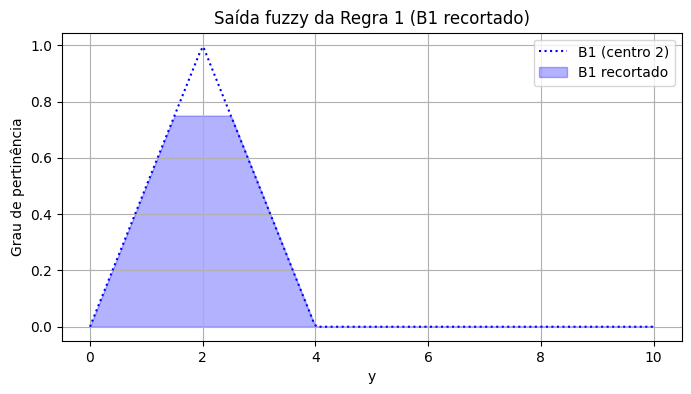

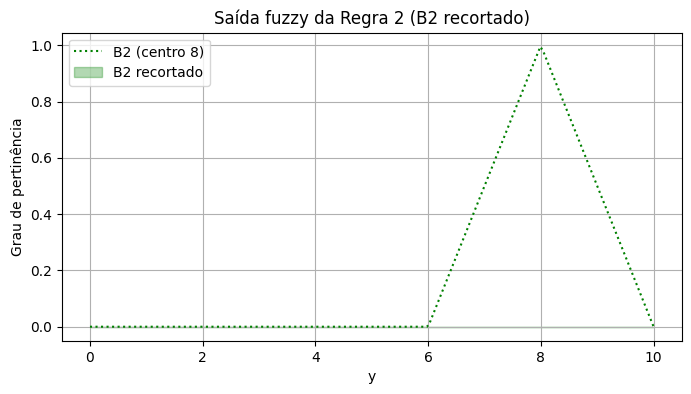

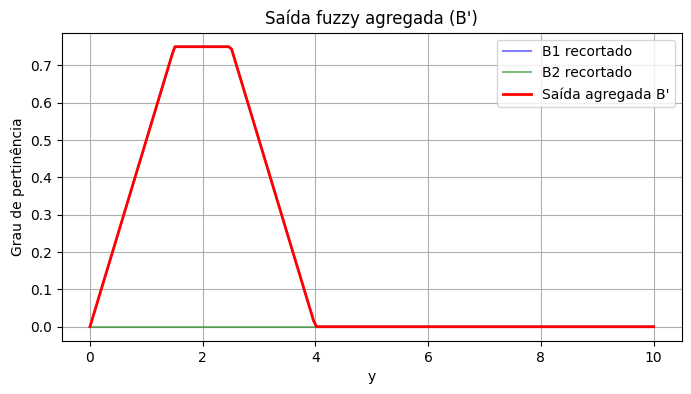

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Universo de entrada e saída
x = np.linspace(0, 10, 200)
y = np.linspace(0, 10, 200)

# Funções de pertinência para as entradas
def A11(x): return np.maximum(0, 1 - np.abs(x - 3)/2)
def A12(x): return np.maximum(0, 1 - np.abs(x - 7)/2)
def A21(x): return np.maximum(0, 1 - np.abs(x - 6)/2)
def A22(x): return np.maximum(0, 1 - np.abs(x - 4)/2)

# Funções de pertinência para as saídas
def B1(y): return np.maximum(0, 1 - np.abs(y - 2)/2)
def B2(y): return np.maximum(0, 1 - np.abs(y - 8)/2)

# Entradas atuais
a1 = 3.5
a2 = 7.0

# Graus de pertinência das entradas nas funções antecedentes
w11 = A11(a1)
w12 = A12(a2)
w21 = A21(a1)
w22 = A22(a2)

# Grau de disparo das regras
w1 = min(w11, w12)
w2 = min(w21, w22)

# Saídas fuzzy das regras (recorte dos consequentes)
B1_corte = np.minimum(w1, B1(y))
B2_corte = np.minimum(w2, B2(y))

# Agregação (união) das saídas fuzzy
B_saida = np.maximum(B1_corte, B2_corte)

# Plot B1 recortado
plt.figure(figsize=(8,4))
plt.plot(y, B1(y), label="B1 (centro 2)", color='blue', linestyle=':')
plt.fill_between(y, B1_corte, color='blue', alpha=0.3, label="B1 recortado")
plt.title("Saída fuzzy da Regra 1 (B1 recortado)")
plt.xlabel("y")
plt.ylabel("Grau de pertinência")
plt.legend()
plt.grid(True)
plt.show()

# Plot B2 recortado
plt.figure(figsize=(8,4))
plt.plot(y, B2(y), label="B2 (centro 8)", color='green', linestyle=':')
plt.fill_between(y, B2_corte, color='green', alpha=0.3, label="B2 recortado")
plt.title("Saída fuzzy da Regra 2 (B2 recortado)")
plt.xlabel("y")
plt.ylabel("Grau de pertinência")
plt.legend()
plt.grid(True)
plt.show()

# Plot da saída agregada
plt.figure(figsize=(8,4))
plt.plot(y, B1_corte, color='blue', alpha=0.5, label="B1 recortado")
plt.plot(y, B2_corte, color='green', alpha=0.5, label="B2 recortado")
plt.plot(y, B_saida, color='red', linewidth=2, label="Saída agregada B'")
plt.title("Saída fuzzy agregada (B')")
plt.xlabel("y")
plt.ylabel("Grau de pertinência")
plt.legend()
plt.grid(True)
plt.show()

**Exemplo detalhado do método de inferência de Larsen (Max-Produto)**

Vamos detalhar cada etapa do processo para duas regras, duas entradas e uma saída, utilizando o método de Larsen (max-produto):

**1. Definição das funções de pertinência:**
- $A_{11}(x)$, $A_{12}(x)$, $A_{21}(x)$, $A_{22}(x)$: funções de pertinência dos antecedentes das regras.
- $B_1(y)$, $B_2(y)$: funções de pertinência dos consequentes das regras.

**2. Valores de entrada:**
- $a_1 = 3.5$
- $a_2 = 7.0$

**3. Cálculo dos graus de pertinência das entradas:**
- $w_{11} = A_{11}(a_1)$: grau de pertinência de $a_1$ em $A_{11}$
- $w_{12} = A_{12}(a_2)$: grau de pertinência de $a_2$ em $A_{12}$
- $w_{21} = A_{21}(a_1)$: grau de pertinência de $a_1$ em $A_{21}$
- $w_{22} = A_{22}(a_2)$: grau de pertinência de $a_2$ em $A_{22}$

**4. Grau de disparo (ativação) de cada regra:**
- $w_1 = \min(w_{11}, w_{12})$: mínimo entre os antecedentes da Regra 1 (AND fuzzy)
- $w_2 = \min(w_{21}, w_{22})$: mínimo entre os antecedentes da Regra 2

**5. Recorte dos consequentes (Larsen - produto):**
- $B'_1(y) = w_1 \cdot B_1(y)$: para cada $y$, multiplica o grau de disparo da regra 1 pelo valor da função $B_1(y)$ (recorte por produto)
- $B'_2(y) = w_2 \cdot B_2(y)$: idem para a regra 2

**6. Agregação das saídas das regras:**
- $B'(y) = \max(B'_1(y), B'_2(y))$: para cada $y$, pega o máximo entre as saídas recortadas das duas regras (união fuzzy)

**Resumo visual:**
- As curvas mostram os conjuntos fuzzy de saída recortados por cada regra (produto).
- A linha vermelha mostra a saída fuzzy global agregada, pronta para defuzzificação.

Esse processo pode ser generalizado para qualquer número de regras e variáveis.

**Método de Kosko e Mizumoto (implicação MIN e soma de conclusões)**

No método de Kosko e Mizumoto, a implicação fuzzy pode ser feita usando o operador mínimo (MIN) ao invés do produto.  
Além disso, quando há mais de uma regra, as conclusões fuzzy de cada regra ($C_i$) são somadas ponto a ponto para formar a saída global $C$:
$$
C = C_1 + C_2 + \ldots + C_n
$$
onde a soma é feita ponto a ponto (não é máximo).

**Passos:**
1. Para cada regra, calcule a saída fuzzy $C_i(z)$ usando a implicação MIN:
   $$
   C_i(z) = \min(w_i, \mu_{C_i}(z))
   $$
   onde $w_i$ é o grau de ativação da regra $i$.
2. Some as conclusões fuzzy de todas as regras:
   $$
   C(z) = \sum_{i=1}^n C_i(z)
   $$
3. O resultado pode ser normalizado se necessário.

**Resumo:**  
- Implicação: mínimo (MIN)
- Agregação: soma ponto a ponto das conclusões fuzzy das regras

Esse método é útil quando se deseja que todas as regras contribuam aditivamente para a saída fuzzy.

**Principais métodos de defuzzificação**

A escolha do método de conversão (defuzzificação) depende da aplicação e do tipo de resultado esperado. Os métodos mais comuns são:

- **Centro da Área (CoA) / Centro de Gravidade / Centróide:**  
  Calcula a abscissa do centro de massa da área sob a curva do conjunto fuzzy de saída.
  $$
  \text{CoA}(Z) = \frac{\sum_{i=1}^n z_i \cdot C(z_i)}{\sum_{i=1}^n C(z_i)}
  $$
  - Favorece valores centrais.
  - Áreas sobrepostas são contadas apenas uma vez (usa máximo).
  - Computacionalmente mais custoso.
  - Áreas maiores têm maior impacto no valor de saída.

- **Centro das Somas (CoS):**  
  Semelhante ao centro da área, mas utiliza a soma das áreas (considera sobreposição).
  $$
  \text{CoS}(Z) = \frac{\sum_{i=1}^n z_i \cdot \sum_{k=1}^{N'} C'_k(z_i)}{\sum_{i=1}^n \sum_{k=1}^{N'} C'_k(z_i)}
  $$
  - Áreas sobrepostas são somadas.
  - Útil quando a agregação das regras é feita por soma.

- **Mínimo, Média e Máximo dos Máximos:**  
  Considera os valores de $z$ onde $C(z)$ atinge o valor máximo.
  - **Mínimo dos máximos:** menor $z$ com $C(z)$ máximo.
  - **Máximo dos máximos:** maior $z$ com $C(z)$ máximo.
  - **Média dos máximos:** média dos $z$ com $C(z)$ máximo.

- **Método das Alturas:**  
  Usa a média ponderada dos centros dos conjuntos consequentes das regras, ponderada pelos graus de ativação das regras.

A seguir, exemplos práticos de defuzzificação para um conjunto fuzzy de saída.

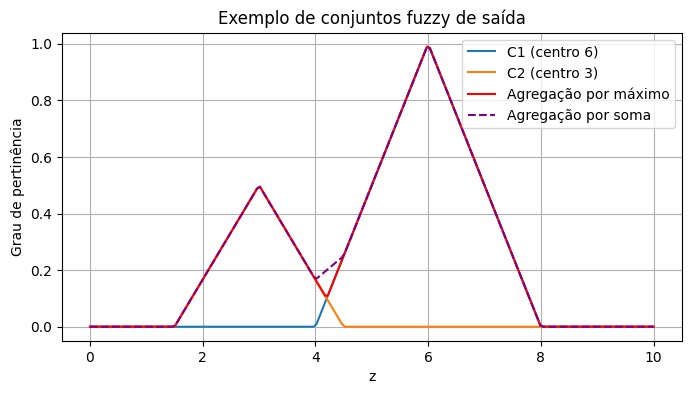

Centro da Área (CoA): 5.19
Centro das Somas (CoS): 5.18
Mínimo dos máximos: 5.98
Máximo dos máximos: 5.98
Média dos máximos: 5.98


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Exemplo de conjunto fuzzy de saída (simulado)
Z = np.linspace(0, 10, 200)
C = np.maximum(0, 1 - np.abs(Z - 6)/2)           # Triangular centrado em 6
C2 = 0.5 * np.maximum(0, 1 - np.abs(Z - 3)/1.5)  # Triangular menor centrado em 3
C_saida = np.maximum(C, C2)                      # Agregação por máximo
C_soma = C + C2                                  # Agregação por soma

plt.figure(figsize=(8,4))
plt.plot(Z, C, label="C1 (centro 6)")
plt.plot(Z, C2, label="C2 (centro 3)")
plt.plot(Z, C_saida, label="Agregação por máximo", color="red")
plt.plot(Z, C_soma, label="Agregação por soma", color="purple", linestyle="--")
plt.title("Exemplo de conjuntos fuzzy de saída")
plt.xlabel("z")
plt.ylabel("Grau de pertinência")
plt.legend()
plt.grid(True)
plt.show()

# Centro da Área (CoA) - máximo
coa = np.sum(Z * C_saida) / np.sum(C_saida)

# Centro das Somas (CoS) - soma
cos = np.sum(Z * C_soma) / np.sum(C_soma)

# Máximos dos máximos
max_val = np.max(C_saida)
z_maximos = Z[C_saida == max_val]
min_max = np.min(z_maximos)
max_max = np.max(z_maximos)
media_max = np.mean(z_maximos)

print(f"Centro da Área (CoA): {coa:.2f}")
print(f"Centro das Somas (CoS): {cos:.2f}")
print(f"Mínimo dos máximos: {min_max:.2f}")
print(f"Máximo dos máximos: {max_max:.2f}")
print(f"Média dos máximos: {media_max:.2f}")

# Resumo das Fórmulas Fundamentais em Sistemas Fuzzy

**Função de pertinência (exemplo triangular):**  
$\mu_A(x) = \max\left(\min\left(\frac{x-a}{b-a}, \frac{c-x}{c-b}\right), 0\right)$

**Operações com conjuntos fuzzy:**  
- União: $\mu_{A \cup B}(x) = \max(\mu_A(x), \mu_B(x))$
- Interseção: $\mu_{A \cap B}(x) = \min(\mu_A(x), \mu_B(x))$
- Complemento: $\mu_{\overline{A}}(x) = 1 - \mu_A(x)$

**α-corte:**  
$A_\alpha = \{x \mid \mu_A(x) \geq \alpha\}$

**Núcleo:**  
$\text{Core}(A) = \{x \mid \mu_A(x) = 1\}$

**Suporte:**  
$\text{Supp}(A) = \{x \mid \mu_A(x) > 0\}$

**Cardinalidade:**  
Discreto: $|A| = \sum_x \mu_A(x)$  
Contínuo: $|A| = \int \mu_A(x) dx$

**T-normas (interseção generalizada):**  
- Mínimo: $T(a, b) = \min(a, b)$
- Produto: $T(a, b) = a \cdot b$
- Lukasiewicz: $T(a, b) = \max(0, a + b - 1)$

**S-normas (união generalizada):**  
- Máximo: $S(a, b) = \max(a, b)$
- Soma probabilística: $S(a, b) = a + b - ab$
- Lukasiewicz: $S(a, b) = \min(1, a + b)$

**Leis de De Morgan (fuzzy):**  
$\overline{A \cup B} = \overline{A} \cap \overline{B}$  
$\overline{A \cap B} = \overline{A} \cup \overline{B}$

**Composição de relações fuzzy:**  
- Max-Min: $\mu_{R \circ S}(u, w) = \max_v [\min(\mu_R(u, v), \mu_S(v, w))]$
- Max-Produto: $\mu_{R \circ S}(u, w) = \max_v [\mu_R(u, v) \cdot \mu_S(v, w)]$

**Defuzzificação (Centroide):**  
$x^* = \frac{\int x \mu_A(x) dx}{\int \mu_A(x) dx}$  
(discreto: $x^* = \frac{\sum x_i \mu_A(x_i)}{\sum \mu_A(x_i)}$)

---